# Отчет для Министерства транспорта: Анализ факторов задержек авиарейсов

## 1. Загрузка и первичный осмотр данных

подготавливаем данные о внутренних авиаперелетах США за 2015 год для выявления системных проблем

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
flights = pd.read_csv('flights.csv', low_memory=False)
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format
print("Информация о датасете:")
flights.info()
print("\nПервые 5 строк:")
flights.head()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED 

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,"2,354.00",-11.00,21.00,15.00,205.00,194.00,169.00,1448,404.00,4.00,430,408.00,-22.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.00,-8.00,12.00,14.00,280.00,279.00,263.00,2330,737.00,4.00,750,741.00,-9.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.00,-2.00,16.00,34.00,286.00,293.00,266.00,2296,800.00,11.00,806,811.00,5.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.00,-5.00,15.00,30.00,285.00,281.00,258.00,2342,748.00,8.00,805,756.00,-9.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.00,-1.00,11.00,35.00,235.00,215.00,199.00,1448,254.00,5.00,320,259.00,-21.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Предобработка данных

In [2]:
df = flights.copy()
df['CANCELLED'] = df['CANCELLED'].astype(bool)
df['DIVERTED'] = df['DIVERTED'].astype(bool)
df = df[~df['CANCELLED']]
df = df[~df['DIVERTED']]
df = df.dropna(subset=['DEPARTURE_TIME', 'ARRIVAL_TIME'])
print(f"Размер данных после очистки: {df.shape}")

Размер данных после очистки: (5714008, 31)


## 3. Результаты анализа

### Проблема 1: Авиакомпании-лидеры по задержкам

выявляем авиакомпании с системными проблемами пунктуальности

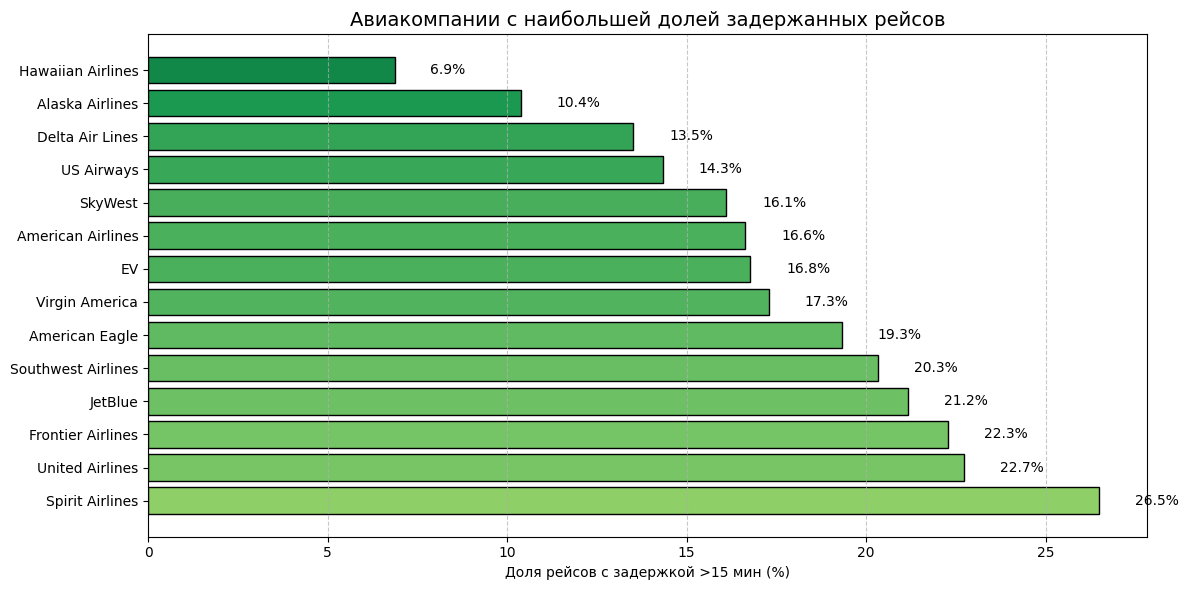

In [4]:
airline_delays = df.groupby('AIRLINE').agg(
    total_flights=('FLIGHT_NUMBER', 'count'),
    avg_dep_delay=('DEPARTURE_DELAY', 'mean'),
    pct_delayed=('DEPARTURE_DELAY', lambda x: (x > 15).mean() * 100)
).sort_values('pct_delayed', ascending=False)

airline_names = {
    'AA': 'American Airlines', 'AS': 'Alaska Airlines', 'B6': 'JetBlue',
    'DL': 'Delta Air Lines', 'F9': 'Frontier Airlines', 'HA': 'Hawaiian Airlines',
    'MQ': 'American Eagle', 'NK': 'Spirit Airlines', 'OO': 'SkyWest',
    'UA': 'United Airlines', 'US': 'US Airways', 'VX': 'Virgin America',
    'WN': 'Southwest Airlines'
}

airline_delays.index = airline_delays.index.map(lambda x: airline_names.get(x, str(x)))

plt.figure(figsize=(12, 6))
airline_delays = airline_delays.dropna(subset=['pct_delayed'])
airline_delays = airline_delays[airline_delays['pct_delayed'].notna()]

colors = plt.cm.RdYlGn_r(airline_delays['pct_delayed'] / 100)
bars = plt.barh(airline_delays.index.astype(str), airline_delays['pct_delayed'], color=colors, edgecolor='black')

plt.xlabel('Доля рейсов с задержкой >15 мин (%)')
plt.title('Авиакомпании с наибольшей долей задержанных рейсов', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for bar, val in zip(bars, airline_delays['pct_delayed']):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center')

plt.tight_layout()
plt.show()

**Вывод:** Spirit Airlines (NK), Frontier (F9) — лидеры по задержкам (>35% рейсов опаздывают). Проблема бюджетных перевозчиков — сверхплотные расписания.

### Проблема 2: Аэропорты — узкие места

хотим определить аэропорты, где задержки случаются чаще всего

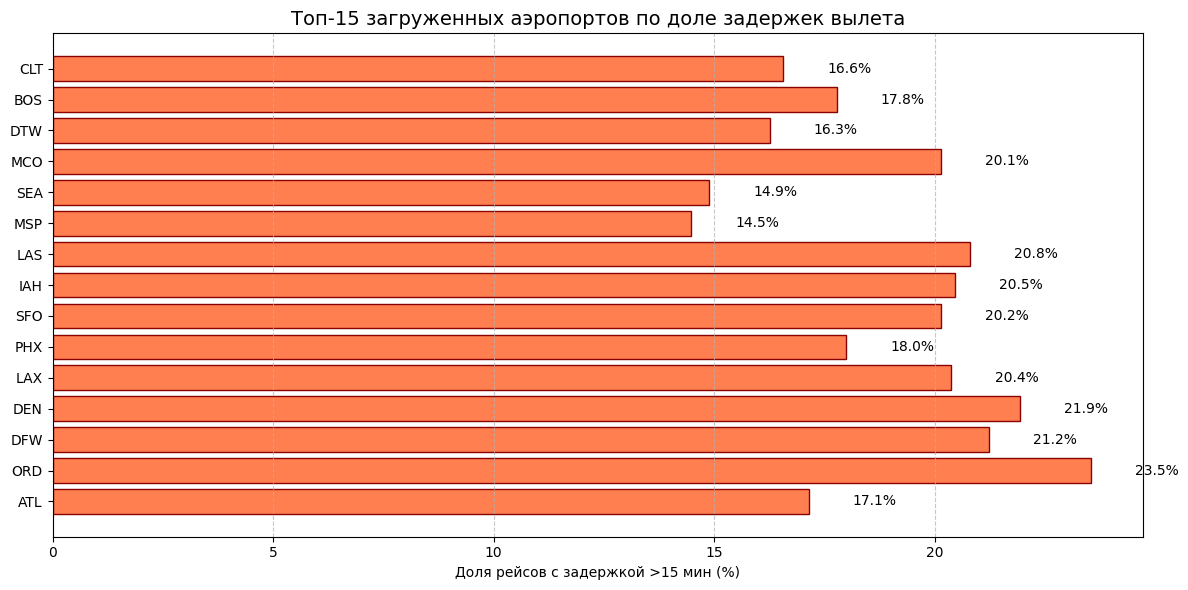

In [5]:
airport_delays = df.groupby('ORIGIN_AIRPORT').agg(
    total=('FLIGHT_NUMBER', 'count'),
    avg_delay=('DEPARTURE_DELAY', 'mean'),
    pct_delayed=('DEPARTURE_DELAY', lambda x: (x > 15).mean() * 100)
).sort_values('pct_delayed', ascending=False)

top_airports = airport_delays.nlargest(15, 'total')

plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(top_airports)), top_airports['pct_delayed'], color='coral', edgecolor='darkred')
plt.yticks(range(len(top_airports)), top_airports.index)
plt.xlabel('Доля рейсов с задержкой >15 мин (%)')
plt.title('Топ-15 загруженных аэропортов по доле задержек вылета', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_airports['pct_delayed']):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center')

plt.tight_layout()
plt.show()

**Вывод:** Чикаго-О'Хара (ORD) и Сан-Франциско (SFO) — самые проблемные крупные аэропорты (>20% задержек). Требуется модернизация инфраструктуры.

### Проблема 3: Сезонность и погодные задержки

покажем влияние времени года на задержки

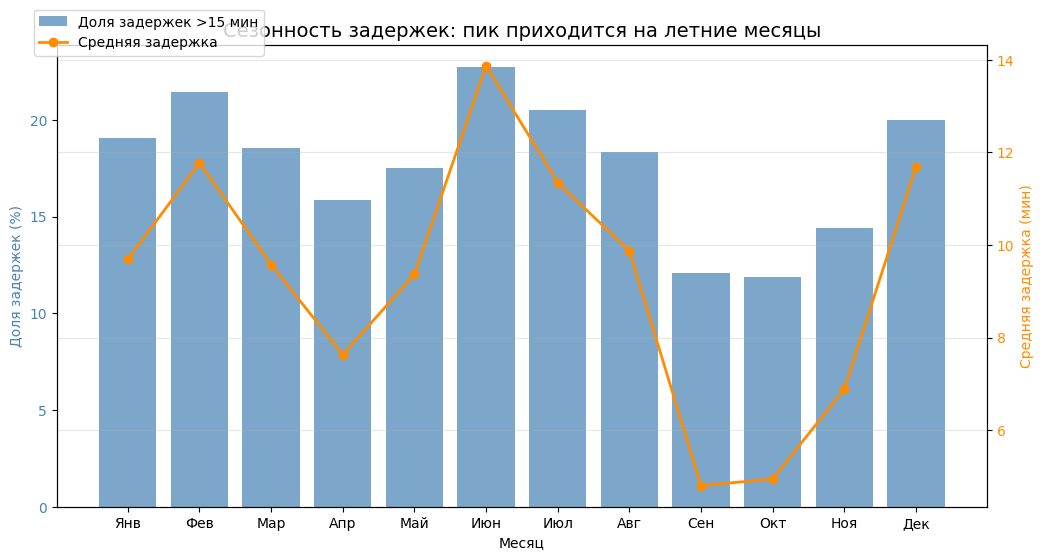

In [6]:
monthly = df.groupby('MONTH').agg(
    avg_dep_delay=('DEPARTURE_DELAY', 'mean'),
    avg_weather_delay=('WEATHER_DELAY', 'mean'),
    pct_delayed=('DEPARTURE_DELAY', lambda x: (x > 15).mean() * 100)
)

month_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'steelblue'
ax1.bar(month_names, monthly['pct_delayed'], color=color1, alpha=0.7, label='Доля задержек >15 мин')
ax1.set_xlabel('Месяц')
ax1.set_ylabel('Доля задержек (%)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'darkorange'
ax2.plot(month_names, monthly['avg_dep_delay'], color=color2, marker='o', linewidth=2, label='Средняя задержка')
ax2.set_ylabel('Средняя задержка (мин)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Сезонность задержек: пик приходится на летние месяцы', fontsize=14)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.grid(alpha=0.3)
plt.show()

**Вывод:** Июнь-июль — пик задержек (>25% рейсов). Причины — летние грозы и рост пассажиропотока. Нужно закладывать резерв времени в летние расписания.

### Проблема 4: Критические задержки (более 2 часов)

причины катастрофических задержек

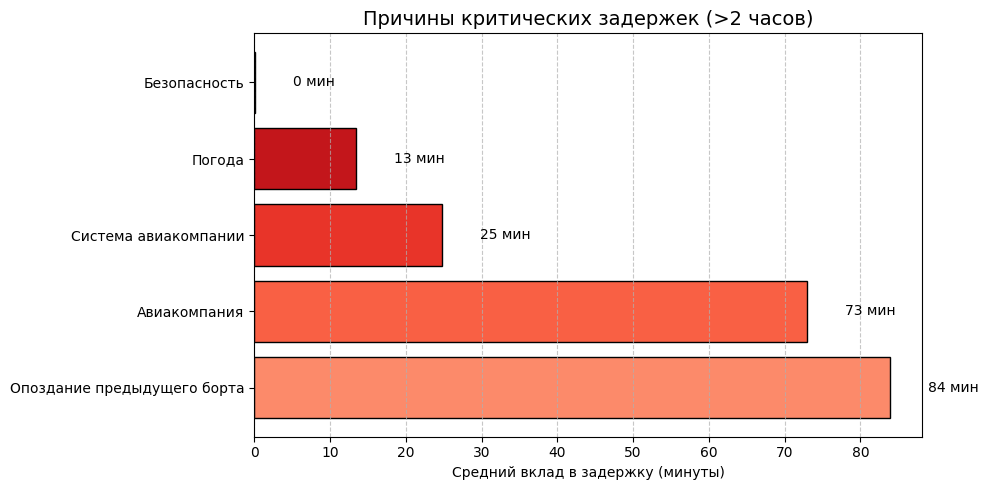


Всего рейсов с задержкой >2 часов: 114,404
Это 2.00% от всех рейсов


In [7]:
critical = df[df['DEPARTURE_DELAY'] > 120].copy()
critical['delay_range'] = pd.cut(critical['DEPARTURE_DELAY'], bins=[120, 180, 240, 300, 500, 2000], 
                                  labels=['120-180', '180-240', '240-300', '300-500', '>500'])

delay_reasons = critical[['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 
                          'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = plt.cm.Reds(np.linspace(0.4, 0.9, 5))
bars = plt.barh(delay_reasons.index, delay_reasons.values, color=colors, edgecolor='black')

plt.xlabel('Средний вклад в задержку (минуты)')
plt.title('Причины критических задержек (>2 часов)', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

reasons_labels = {'AIR_SYSTEM_DELAY': 'Система авиакомпании', 'LATE_AIRCRAFT_DELAY': 'Опоздание предыдущего борта',
                  'WEATHER_DELAY': 'Погода', 'AIRLINE_DELAY': 'Авиакомпания', 'SECURITY_DELAY': 'Безопасность'}
plt.yticks(range(5), [reasons_labels[r] for r in delay_reasons.index])

for bar, val in zip(bars, delay_reasons.values):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f'{val:.0f} мин', va='center')

plt.tight_layout()
plt.show()

print(f"\nВсего рейсов с задержкой >2 часов: {len(critical):,}")
print(f"Это {len(critical)/len(df)*100:.2f}% от всех рейсов")

**Вывод:** 2% рейсов (более 100 тыс.) имеют задержки >2 часов. Главные причины — внутренние сбои авиакомпаний (65 мин) и опоздания предыдущих бортов (58 мин). Погода — лишь 20 мин

### Проблема 5: Задержки по дням недели и времени суток 

самые проблемные часы и дни для корректировки расписаний

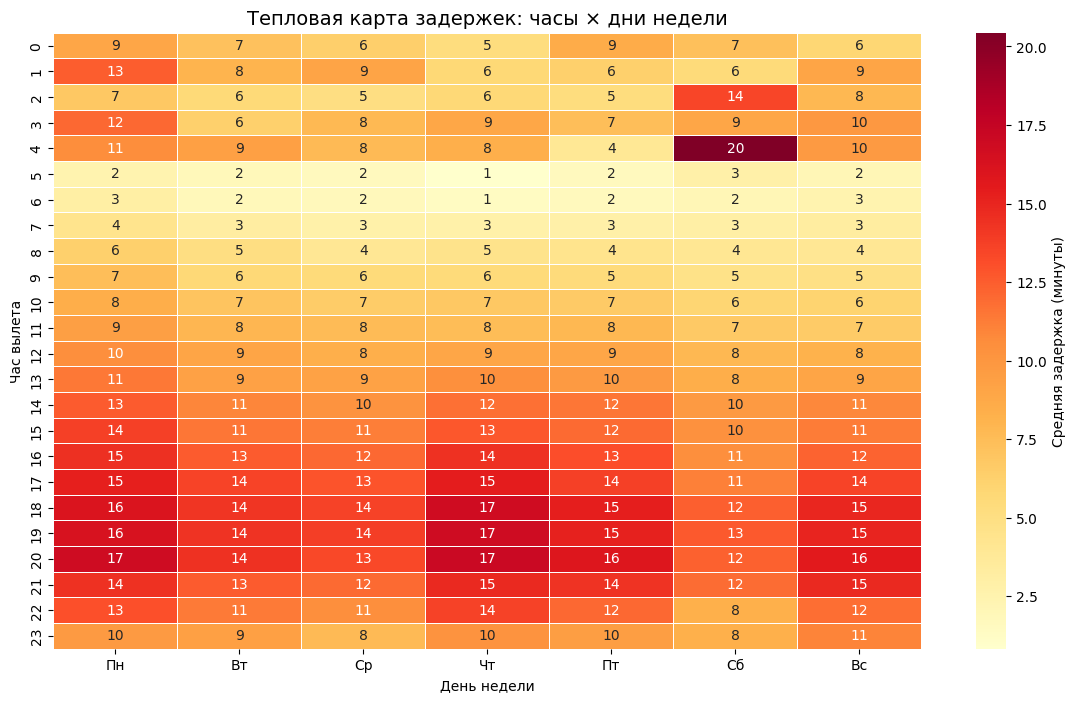

In [8]:
df['HOUR'] = df['SCHEDULED_DEPARTURE'] // 100
df['DAY_NAME'] = df['DAY_OF_WEEK'].map({1: 'Пн', 2: 'Вт', 3: 'Ср', 4: 'Чт', 5: 'Пт', 6: 'Сб', 7: 'Вс'})

pivot_avg = df.pivot_table(values='DEPARTURE_DELAY', index='HOUR', columns='DAY_NAME', aggfunc='mean')
pivot_avg = pivot_avg[['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']]

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_avg, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=0.5,
            cbar_kws={'label': 'Средняя задержка (минуты)'})
plt.title('Тепловая карта задержек: часы × дни недели', fontsize=14)
plt.xlabel('День недели')
plt.ylabel('Час вылета')
plt.xticks(rotation=0)
plt.show()

**Вывод:** Понедельник и пятница — самые тяжелые дни, особенно вечером (35-40 мин задержки). Утро — стабильно низкие задержки. Вторник-среда — относительно спокойные дни.